In [1]:
print("Agent Ready to Run!!!")

Agent Ready to Run!!!


In [2]:
from groq import Groq
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import SystemMessage
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langchain_core.prompts import ChatPromptTemplate

In [3]:
from langchain_groq import ChatGroq

In [4]:
import os
from typing import TypedDict

In [5]:
load_dotenv()

True

In [6]:
groq_api_key = os.getenv("GROQ_API_KEY")

In [7]:
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.7)

In [ ]:
# class AgentState(TypedDict):
#     messages = MessagesState()

In [8]:
store = InMemoryStore()

user_id = "u1"

user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Shayan"})
store.put(user_details, "profile_2", {"data": "Profession: AI Engineer"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project) and AI/Ml projects"})

In [9]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [10]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", SYSTEM_PROMPT_TEMPLATE),
        ("placeholder", "{messages}")
    ]
)

chain = prompt | llm

In [ ]:
# chat_completions = client.chat.completions.create(
#         messages=[{
#             "role":"user",
#             "content": SYSTEM_PROMPT_TEMPLATE
#         }
#         ],
#         model="llama-3.1-8b-instant",
#         temperature=0.7
#     )

In [16]:
# def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
#     user_id = config['configurable']['user_id']
#     user_details = ("user", user_id,"details")
#     items = store.search(user_details)
    
#     if items:
#         user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
#     else:
#         user_details_content = ""

#     system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
#         user_details_content = user_details_content
#     )

#     system_msg = SystemMessage(content=system_prompt)

#     response = chain.invoke([system_msg] + state.messages)
#     return {"messages": [response]}
    

def chat_node(
    state: MessagesState,
    config: RunnableConfig,
    store: BaseStore
):
    user_id = config["configurable"]["user_id"]

    items = store.search(("user", user_id, "details"))

    user_details_content = "\n".join(
        f"- {item.value.get('data', '')}"
        for item in items
    )

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    messages = [
        SystemMessage(content=system_prompt),
        *state["messages"]
    ]

    response = llm.invoke(messages)

    return {
        "messages": [response]
    }

In [17]:
builder = StateGraph(MessagesState)

builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

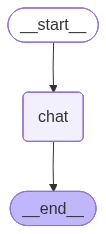

In [18]:
graph

In [20]:
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages":[{"role": "user", "content": "Explain gen ai in clear wordings"}]},
    config,
)

print(result["messages"][-1].content)
# print(result)

Hey Shayan, I know you're working with AI and ML projects, so I'll give you a concise explanation of Generalized AI (Gen AI).

Gen AI refers to a type of artificial intelligence that can perform a wide range of tasks across various domains, similar to how humans think and learn. Unlike Narrow or Specialized AI, which is designed for specific tasks like image recognition or language translation, Gen AI aims to create a single AI system that can generalize and apply its knowledge to various situations.

Think of it like a human who can understand a question and respond with an answer that's relevant to the conversation, without needing to be explicitly programmed for every possible scenario.

In your MCP server project, you might be interested in integrating Gen AI capabilities to enhance the server's decision-making and problem-solving abilities.

Here's a simple Python example to illustrate the concept:
```python
import numpy as np

# Define a basic Gen AI model using a neural network


In [26]:
response = llm.invoke("what is my name?")
print(response)

content="I don't have any information about your name. I'm a large language model, I don't retain any personal information or context about individual users. Each time you interact with me, it's a new conversation. If you'd like to share your name with me, I'd be happy to chat with you!" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 40, 'total_tokens': 104, 'completion_time': 0.072751002, 'completion_tokens_details': None, 'prompt_time': 0.002131774, 'prompt_tokens_details': None, 'queue_time': 0.303203626, 'total_time': 0.074882776}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4848f70c04', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019ebaa3-3f14-7fe2-9ef2-e1cdda3d65a0-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 40, 'output_tokens': 64, 'total_tokens': 104}


In [69]:
def message_node(state: MessagesState):
    response = llm.invoke(state['messages'])
    return {"messages": [response]}

In [71]:
builder1 = StateGraph(MessagesState)
builder1.add_node("call_model", message_node)
builder1.add_edge(START, "call_model")

graph1 = builder1.compile()

In [72]:
graph1.invoke({"messages": [{"role":"user", "content": "Hi! my name is shayan"}]})

{'messages': [HumanMessage(content='Hi! my name is shayan', additional_kwargs={}, response_metadata={}, id='949d1d5b-d362-4321-8015-25afb2f122fe'),
  AIMessage(content="Hello Shayan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 42, 'total_tokens': 69, 'completion_time': 0.024645602, 'completion_tokens_details': None, 'prompt_time': 0.01150924, 'prompt_tokens_details': None, 'queue_time': 0.34294452, 'total_time': 0.036154842}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebb37-0797-7820-8f32-caa94f5be234-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 27, 'total_tokens': 69})]}

In [73]:
graph1.invoke({"messages": [{"role":"user", "content": "What is my name"}]})

{'messages': [HumanMessage(content='What is my name', additional_kwargs={}, response_metadata={}, id='9c3140a2-abe4-41e7-96a7-9d2b5634f5cd'),
  AIMessage(content="I don't have that information. I'm a large language model, I don't have the ability to retain personal information about individual users. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations.\n\nIf you'd like, you can tell me your name and I can use it in our conversation.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 39, 'total_tokens': 111, 'completion_time': 0.092085048, 'completion_tokens_details': None, 'prompt_time': 0.003120995, 'prompt_tokens_details': None, 'queue_time': 0.195370123, 'total_time': 0.095206043}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--0

In [76]:
builder2 = StateGraph(MessagesState)
builder2.add_node("call_model", message_node)
builder2.add_edge(START, "call_model")



In [79]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()

In [ ]:
graph_with_memory = builder2.compile(checkpointer=checkpointer)

In [83]:
config = {"configurable": {"thread_id": "thread-1"}}

In [84]:
graph_with_memory.invoke({"messages": [{"role": "user", "content": "Hi my name is shayan umar"}]}, config)

{'messages': [HumanMessage(content='Hi my name is shayan umar', additional_kwargs={}, response_metadata={}, id='a67b7937-4016-45d7-98a4-733dda8f448a'),
  AIMessage(content='Nice to meet you, Shayan Umar. How are you today? Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 43, 'total_tokens': 74, 'completion_time': 0.03848034, 'completion_tokens_details': None, 'prompt_time': 0.002078335, 'prompt_tokens_details': None, 'queue_time': 0.213109005, 'total_time': 0.040558675}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebb4a-5076-77e2-9d92-3fbd860f4f95-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 31, 'total_tokens': 74})]}

In [85]:
graph_with_memory.invoke({"messages": [{"role": "user", "content": "can u tell me what is my name i think i lost it"}]}, config)

{'messages': [HumanMessage(content='Hi my name is shayan umar', additional_kwargs={}, response_metadata={}, id='a67b7937-4016-45d7-98a4-733dda8f448a'),
  AIMessage(content='Nice to meet you, Shayan Umar. How are you today? Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 43, 'total_tokens': 74, 'completion_time': 0.03848034, 'completion_tokens_details': None, 'prompt_time': 0.002078335, 'prompt_tokens_details': None, 'queue_time': 0.213109005, 'total_time': 0.040558675}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebb4a-5076-77e2-9d92-3fbd860f4f95-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 31, 'total_tokens': 74}),
  HumanMessage(content='can u tell me what is my name i thin

In [86]:
snap = graph_with_memory.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
    print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi my name is shayan umar
- AIMessage : Nice to meet you, Shayan Umar. How are you today? Is there something I can help you with or would you like to chat?
- HumanMessage : can u tell me what is my name i think i lost it
- AIMessage : Don't worry, I've got you covered. Your name is Shayan Umar. I remember you telling me that just a few minutes ago.


In [88]:
vals =  graph_with_memory.get_state(config).values
print(vals)

{'messages': [HumanMessage(content='Hi my name is shayan umar', additional_kwargs={}, response_metadata={}, id='a67b7937-4016-45d7-98a4-733dda8f448a'), AIMessage(content='Nice to meet you, Shayan Umar. How are you today? Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 43, 'total_tokens': 74, 'completion_time': 0.03848034, 'completion_tokens_details': None, 'prompt_time': 0.002078335, 'prompt_tokens_details': None, 'queue_time': 0.213109005, 'total_time': 0.040558675}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ebb4a-5076-77e2-9d92-3fbd860f4f95-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 31, 'total_tokens': 74}), HumanMessage(content='can u tell me what is my name i think i 